In [ ]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae

# Candidate: ARIMA

AutoARIMA: optimized parameters (p,i, q, P,Q)

In [ ]:
import marimo as mo

from unwind.pipelines.baseline_models.baseline_v0 import (
    preprocess_sales_data,
    plot_baseline_v0_evaluation,
)

In [ ]:
from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project
from pathlib import Path

PROJECT_ROOT = "unwind"
CWD = Path.cwd()
try:
    idx = CWD.parts.index(PROJECT_ROOT)
    PROJECT_PATH = Path(*CWD.parts[: idx + 1])
except ValueError:
    PROJECT_PATH = CWD

bootstrap_project(PROJECT_PATH)

with KedroSession.create(PROJECT_PATH, False) as session:
    context = session.load_context()
    catalog = context.catalog

    ds_raw = catalog.load("raw_ingestion.ds_daily_sales")

[03/01/26 12:57:34] INFO     Registering new       mlflow_hook.py:65
                             custom resolver:                       
                             'km.random_name'                       
                    INFO     Loading data from  data_catalog.py:1048
                             raw_ingestion.ds_d                     
                             aily_sales                             
                             (MlflowCSVDataset)                     
                             ...                                    


In [ ]:
ds_raw

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-13\",\"y\":10.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-14\",\"y\":0.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-15\",\"y\":0.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-16\",\"y\":10.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-17\",\"y\":30.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-18\",\"y\":0.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-19\",\"y\":10.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-20\",\"y\":0.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-21\",\"y\":10.0,\"unit_price\":10.0},{\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-22\",\"y\":0.0,\"unit_price\":10.0}]"' data-total-rows='57046' data-total-columns='4' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["unique_id",["string","object"]],["ds",["string","object"]],["y",["number","float64"]],["unit_price",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

In [ ]:
ds_train_itm = preprocess_sales_data(ds_raw)

In [ ]:
ds_train_itm

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":0,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-13 00:00:00\",\"y\":10.0},{\"\":1,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-14 00:00:00\",\"y\":0.0},{\"\":2,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-15 00:00:00\",\"y\":0.0},{\"\":3,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-16 00:00:00\",\"y\":10.0},{\"\":4,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-17 00:00:00\",\"y\":30.0},{\"\":5,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-18 00:00:00\",\"y\":0.0},{\"\":6,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-19 00:00:00\",\"y\":10.0},{\"\":7,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-20 00:00:00\",\"y\":0.0},{\"\":8,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-21 00:00:00\",\"y\":10.0},{\"\":9,\"unique_id\":\"12 MACARON\",\"ds\":\"2022-07-22 00:00:00\",\"y\":0.0}]"' data-total-rows='56904' data-total-columns='3' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["unique_id",["string","object"]],["ds",["datetime","datetime64[ns]"]],["y",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["",["integer","int64"]]]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>

In [ ]:
def evaluate_candidate_models(
    data: pd.DataFrame, horizon: int, models
) -> pd.DataFrame:
    """Evaluates baseline models using a simple validation split."""
    # Split into train and validation
    ds_val = data.groupby("unique_id").tail(horizon)
    ds_train_n = data.drop(ds_val.index).reset_index(drop=True)

    sf = StatsForecast(models, freq="D")
    sf.fit(ds_train_n)

    tt_preds = sf.predict(h=horizon)
    ds_eval = pd.merge(ds_val, tt_preds, "left", ["ds", "unique_id"])

    evaluation = evaluate(ds_eval, metrics=[mae])
    # Average metrics across all unique_ids
    final_evaluation = (
        evaluation.drop(columns=["unique_id"])
        .groupby("metric")
        .mean()
        .reset_index()
    )
    return final_evaluation

In [ ]:
HORIZON = 7
evaluation_results = evaluate_candidate_models(
    ds_train_itm,
    HORIZON,
    models=[
        AutoARIMA(seasonal=False, alias="ARIMA"),
        AutoARIMA(season_length=7, alias="SARIMA"),
    ],
)
evaluation_results

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"metric\":\"mae\",\"ARIMA\":5.001154803259688,\"SARIMA\":4.3076437889149295}]"' data-total-rows='1' data-total-columns='3' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["metric",["string","object"]],["ARIMA",["number","float64"]],["SARIMA",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='"df"'>


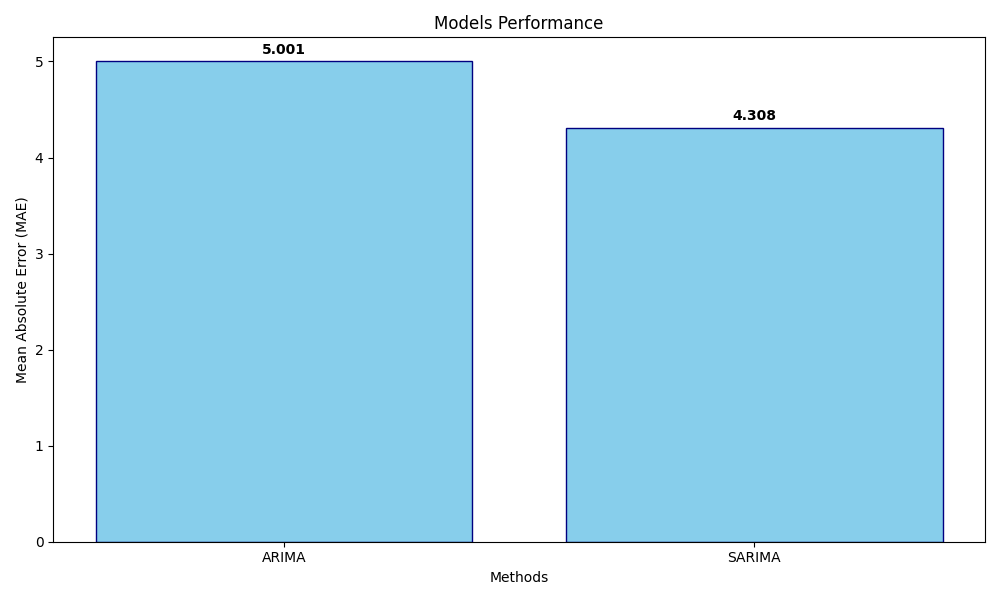

In [ ]:
mo.ui.matplotlib(plot_baseline_v0_evaluation(evaluation_results).gca())